# 💳 Credit Card Fraud Detection

**Goal:** Detect fraudulent credit card transactions using ML models.

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
284,807 transactions, 492 frauds (0.17%)

---

### Pipeline
1. Data Loading
2. EDA
3. Preprocessing
4. Logistic Regression (Baseline)
5. XGBoost
6. PR-AUC
7. SHAP
8. Threshold Tuning
9. Summary

## Step 1 — Imports & Data Loading

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve,
    roc_auc_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")



In [20]:
df = pd.read_csv("creditcard.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df.describe().round(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


## Step 2 — EDA (Exploratory Data Analysis)

In [22]:
class_counts = df["Class"].value_counts()
fraud_pct = class_counts[1] / len(df) * 100

print(f"Normal transactions:  {class_counts[0]:,}")
print(f"Fraudulent:           {class_counts[1]:,}  ({fraud_pct:.3f}%)")

Normal transactions:  284,315
Fraudulent:           492  (0.173%)


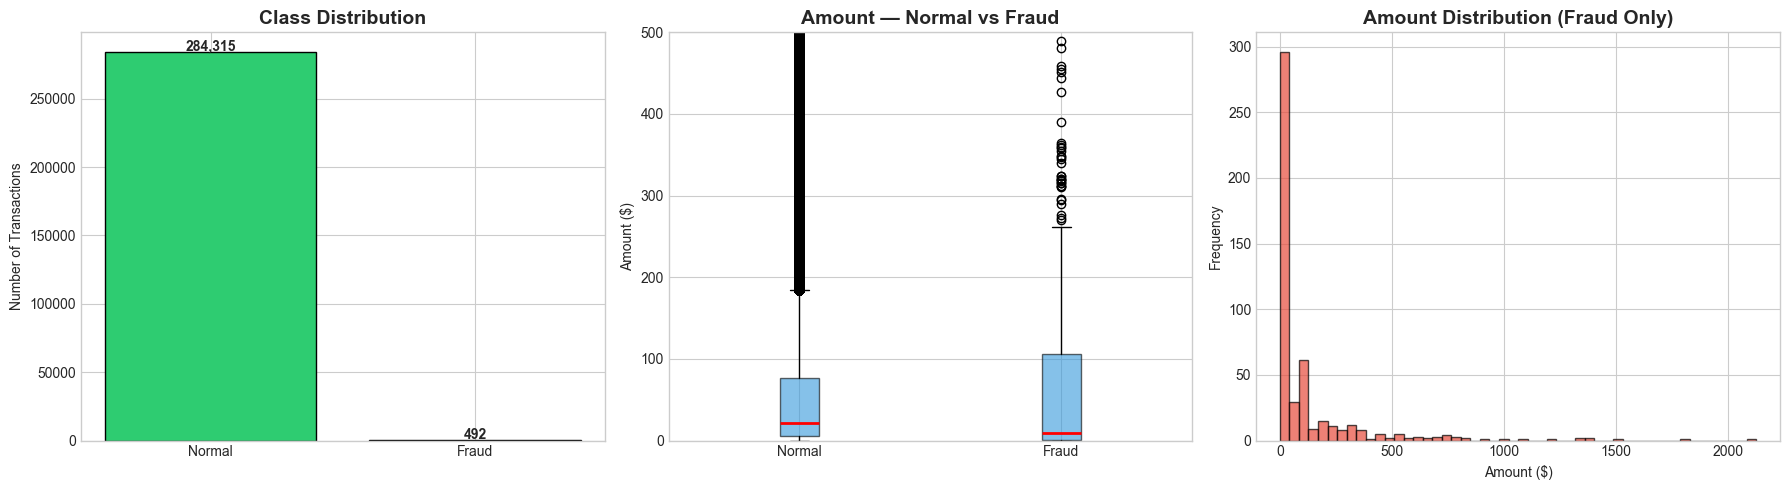

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["Normal", "Fraud"], class_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Transactions")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# Amount boxplot
df_normal = df[df["Class"] == 0]["Amount"]
df_fraud = df[df["Class"] == 1]["Amount"]
axes[1].boxplot([df_normal, df_fraud], labels=["Normal", "Fraud"],
                patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.6),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Amount — Normal vs Fraud", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Amount ($)")
axes[1].set_ylim(0, 500)

# Fraud amount histogram
axes[2].hist(df_fraud, bins=50, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[2].set_title("Amount Distribution (Fraud Only)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Amount ($)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

In [24]:
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df.drop(["Amount", "Time"], axis=1, inplace=True)

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} samples ({y_train.sum()} frauds)")
print(f"Test set:  {X_test.shape[0]:,} samples ({y_test.sum()} frauds)")
print(f"Fraud ratio (train): {y_train.mean():.4f}")
print(f"Fraud ratio (test):  {y_test.mean():.4f}")

Train set: 227,845 samples (394 frauds)
Test set:  56,962 samples (98 frauds)
Fraud ratio (train): 0.0017
Fraud ratio (test):  0.0017


## Step 4 — Baseline: Logistic Regression

In [25]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Classification Report — Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr, target_names=["Normal", "Fraud"]))

Classification Report — Logistic Regression:

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



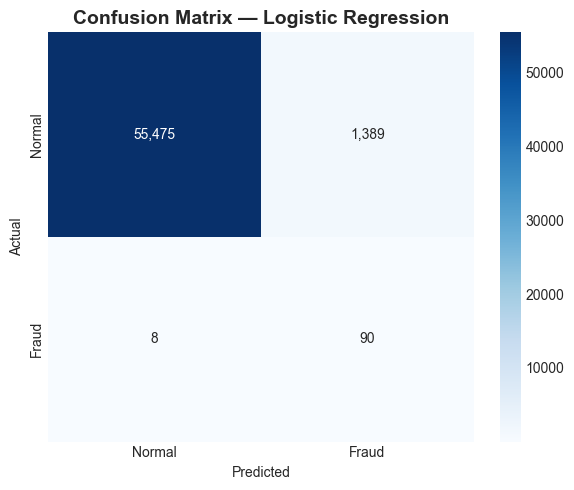

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"], ax=ax)
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## Step 5 — XGBoost

In [27]:
n_normal = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
spw = n_normal / n_fraud
print(f"scale_pos_weight = {spw:.1f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="aucpr",
    use_label_encoder=False,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\nClassification Report — XGBoost:\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Normal", "Fraud"]))

scale_pos_weight = 577.3

Classification Report — XGBoost:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



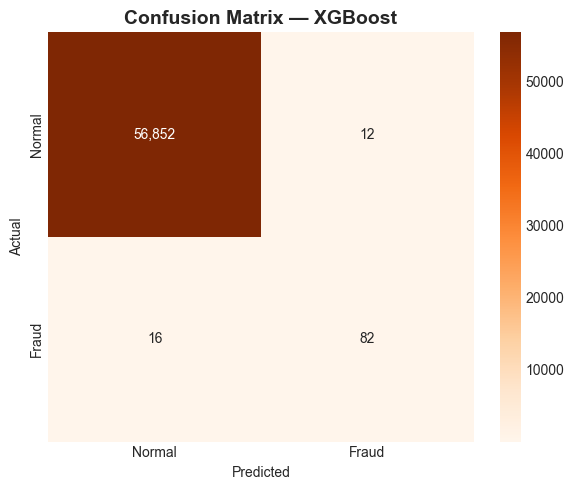

In [28]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt=",d", cmap="Oranges",
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"], ax=ax)
ax.set_title("Confusion Matrix — XGBoost", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## Step 6 — PR-AUC (Precision-Recall Curve)

PR-AUC  Logistic Regression: 0.7189
PR-AUC  XGBoost:             0.8810


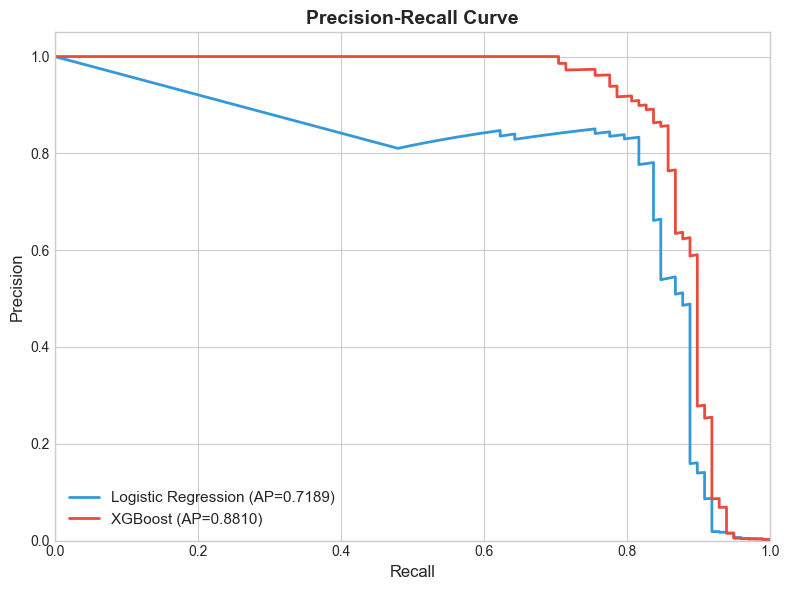

In [29]:
ap_lr = average_precision_score(y_test, y_prob_lr)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

print(f"PR-AUC  Logistic Regression: {ap_lr:.4f}")
print(f"PR-AUC  XGBoost:             {ap_xgb:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP={ap_lr:.4f})",
        linewidth=2, color="#3498db")
ax.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP={ap_xgb:.4f})",
        linewidth=2, color="#e74c3c")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Step 7 — SHAP (Feature Importance)

In [30]:
# Using 1000 samples for speed
X_sample = X_test.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed ✅")

SHAP values computed ✅


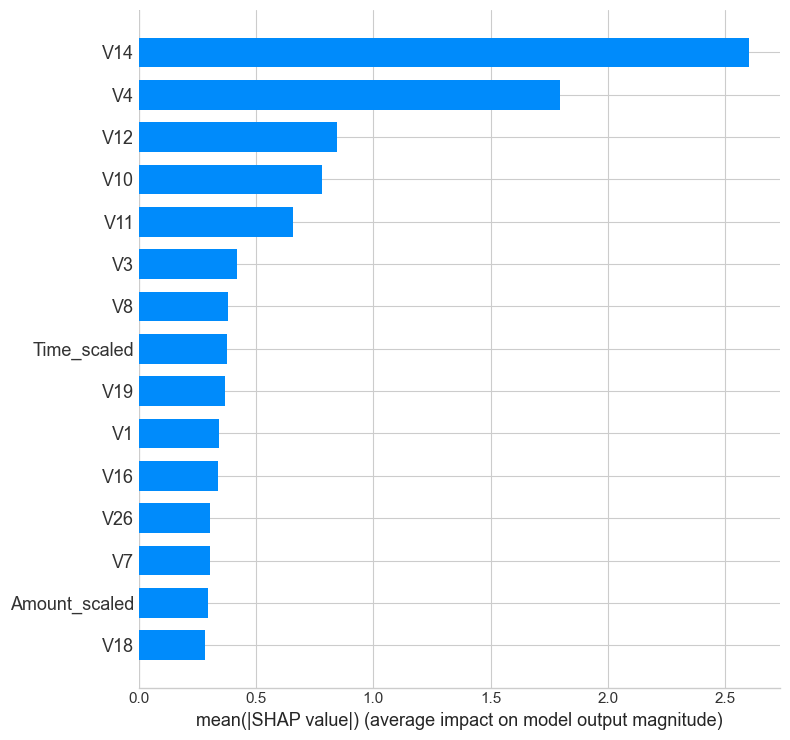

In [31]:
# Bar plot — top 15 features
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15)

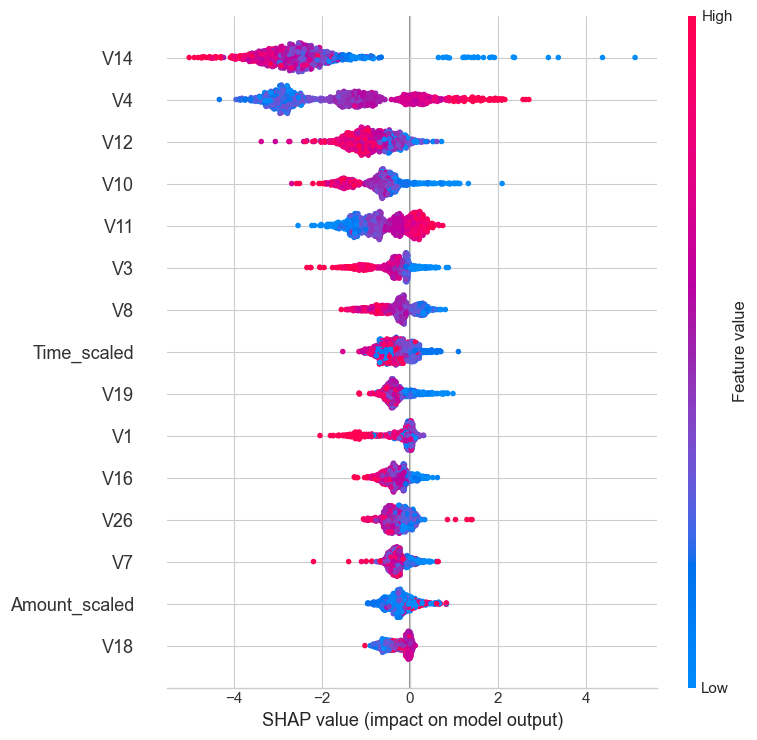

In [32]:
# Beeswarm plot
shap.summary_plot(shap_values, X_sample, max_display=15)

## Step 8 — Threshold Tuning

In [33]:
thresholds = np.arange(0.01, 1.0, 0.01)
precisions_t = []
recalls_t = []
f1_scores_t = []

for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    precisions_t.append(prec)
    recalls_t.append(rec)
    f1_scores_t.append(f1)

best_idx = np.argmax(f1_scores_t)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores_t[best_idx]

print(f"Optimal threshold (max F1): {best_threshold:.2f}")
print(f"F1 score:   {best_f1:.4f}")
print(f"Precision:  {precisions_t[best_idx]:.4f}")
print(f"Recall:     {recalls_t[best_idx]:.4f}")

Optimal threshold (max F1): 0.64
F1 score:   0.8632
Precision:  0.8913
Recall:     0.8367


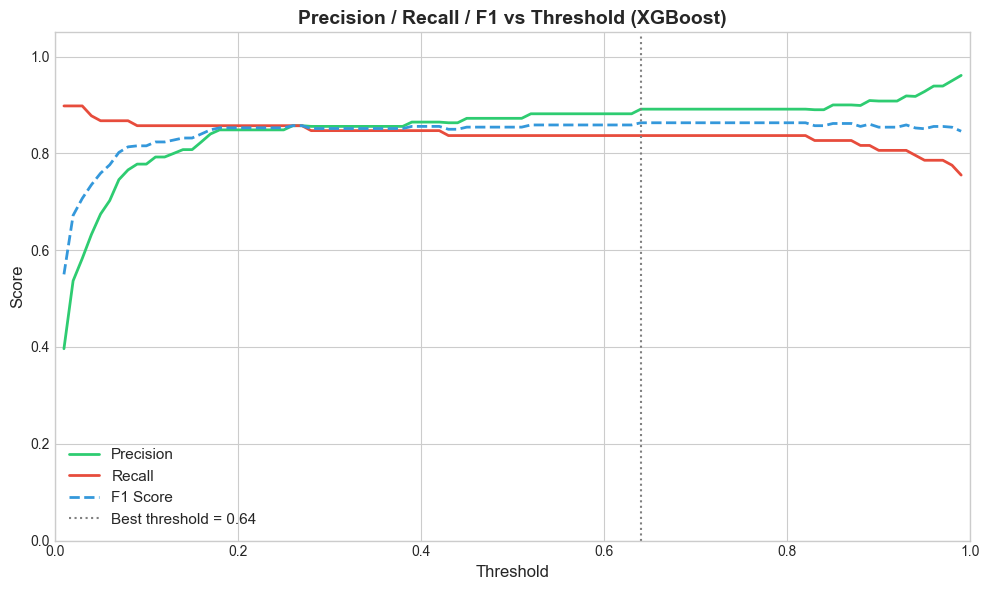

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions_t, label="Precision", linewidth=2, color="#2ecc71")
ax.plot(thresholds, recalls_t, label="Recall", linewidth=2, color="#e74c3c")
ax.plot(thresholds, f1_scores_t, label="F1 Score", linewidth=2, color="#3498db", linestyle="--")
ax.axvline(x=best_threshold, color="gray", linestyle=":", linewidth=1.5,
           label=f"Best threshold = {best_threshold:.2f}")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision / Recall / F1 vs Threshold (XGBoost)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Step 9 — Summary & Model Comparison

In [35]:
roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost (default 0.5)", f"XGBoost (threshold={best_threshold:.2f})"],
    "Precision (Fraud)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precisions_t[best_idx],
    ],
    "Recall (Fraud)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recalls_t[best_idx],
    ],
    "F1 (Fraud)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        best_f1,
    ],
    "PR-AUC": [ap_lr, ap_xgb, ap_xgb],
    "ROC-AUC": [roc_lr, roc_xgb, roc_xgb],
})

results.style.format("{:.4f}", subset=results.columns[1:]).set_caption("Model Comparison")

,Model,Precision (Fraud),Recall (Fraud),F1 (Fraud),PR-AUC,ROC-AUC
0,Logistic Regression,0.0609,0.9184,0.1141,0.7189,0.9722
1,XGBoost (default 0.5),0.8723,0.8367,0.8542,0.8810,0.9724
2,XGBoost (threshold=0.64),0.8913,0.8367,0.8632,0.8810,0.9724


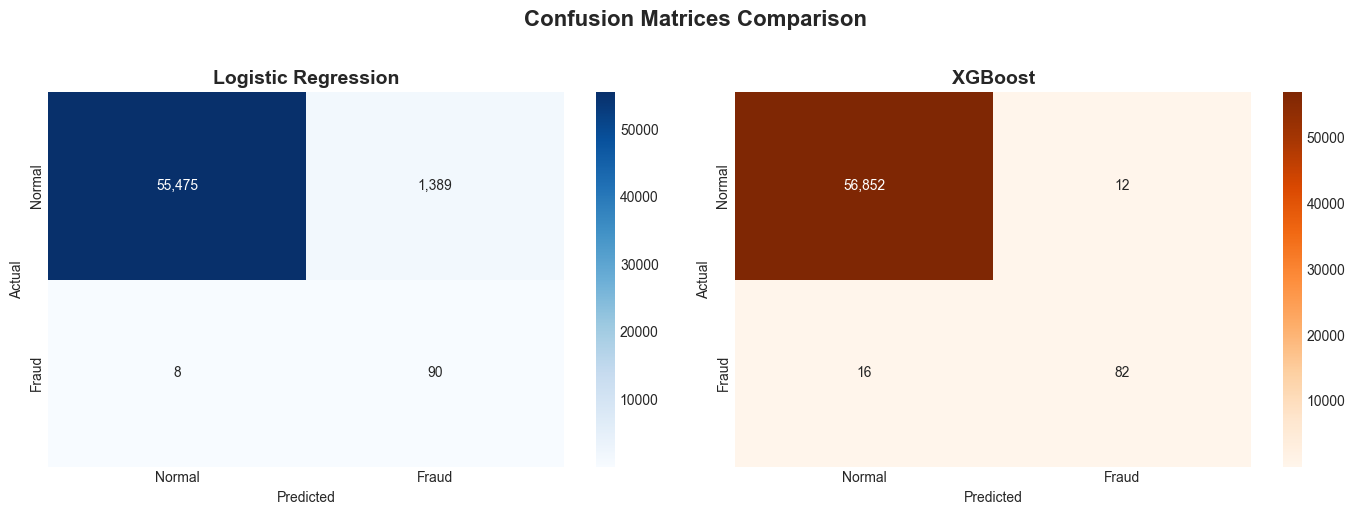

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in [
    (axes[0], cm_lr, "Logistic Regression", "Blues"),
    (axes[1], cm_xgb, "XGBoost", "Oranges"),
]:
    sns.heatmap(cm, annot=True, fmt=",d", cmap=cmap,
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"], ax=ax)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

